Let's evaluate each feature separately

In [12]:
import pandas as pd

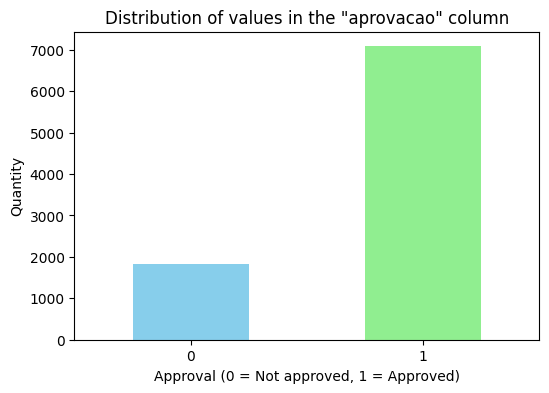

In [13]:
# Load the required files
vote_sessions = pd.read_csv("../data/vote_sessions_full.csv", usecols=["id", "data", "aprovacao", "propositionID", "siglaOrgao", "year", "author_type", "num_authors", "theme", "legislatura", "Governo", "Oposição", "GOV."])
content_cluster = pd.read_csv("../Content/prop_content.csv", usecols=["id", "content"])
authors_pop = pd.read_csv("../Author's Popularity/author_popularity.csv", usecols=["idVotacao", "popularity"])
authors_comm = pd.read_csv("../Author's Group/authors_community_dataset_one_year_window.csv", usecols=["id", "author_prev_community", "prev_community_0_size", "prev_community_1_size", "prev_community_2_size"])

# Merge vote_sessions with content_cluster
merged_df = vote_sessions.merge(
    content_cluster, left_on="id", right_on="id", how="left"
)

# Merge with authors_pop (id in vote_sessions matches idVotacao in authors_pop)
merged_df = merged_df.merge(
    authors_pop, left_on="id", right_on="idVotacao", how="left"
)

# Merge with authors_comm (id in vote_sessions matches id in authors_comm)
merged_df = merged_df.merge(
    authors_comm, left_on="id", right_on="id", how="left"
)

# Remove duplicated columns: "propositionID", "idVotacao"
merged_df = merged_df.drop(columns=["propositionID", "idVotacao"])

# Keep only unique values of the 'id' column
merged_df = merged_df.drop_duplicates(subset=["id"], keep="first")

def resolve_gov_orientation(row):
    if row['GOV.'] == row['Governo']:
        return row['GOV.']
    else:
        # Se discordam, retorna o valor diferente de zero (1 ou -1)
        if row['GOV.'] != 0:
            return row['GOV.']
        else:
            return row['Governo']

merged_df['gov_orientation'] = merged_df.apply(resolve_gov_orientation, axis=1)

# Convert the 'data' column to datetime
merged_df['data'] = pd.to_datetime(merged_df['data'], errors='coerce')

# Convert the 'aprovacao' column to int
merged_df['aprovacao'] = pd.to_numeric(merged_df['aprovacao'], errors='coerce').astype('Int64')

# Convert the community size columns to int
for col in ['prev_community_0_size', 'prev_community_1_size', 'prev_community_2_size']:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce').astype('Int64')

# Truncate 'num_authors' values at 10, keeping values <=10 as is
merged_df['num_authors_trunc'] = merged_df['num_authors'].apply(lambda x: x if x <= 10 else 10)

# Create a new boolean column to tag propositions with more than 10 authors
merged_df['has_more_than_10_authors'] = merged_df['num_authors'] > 10


merged_df['popularity'] = merged_df['popularity'].fillna(0)

# Substituir valores N/A na coluna 'author_prev_community' por -1 
# (valor fora do intervalo 0-2 para indicar "comunidade desconhecida")
merged_df['author_prev_community'] = merged_df['author_prev_community'].fillna(-1)

merged_df = merged_df.dropna(subset=['aprovacao'])

# Preencher valores nulos na coluna 'theme' com "Not defined"
merged_df['theme'] = merged_df['theme'].fillna("Not defined")

# Preencher valores nulos nas colunas 'prev_community_0_size' e 'prev_community_1_size' com zero
merged_df['prev_community_0_size'] = merged_df['prev_community_0_size'].fillna(0)
merged_df['prev_community_1_size'] = merged_df['prev_community_1_size'].fillna(0)

import matplotlib.pyplot as plt

# Count the values 0 and 1 in the 'aprovacao' column
approval_counts = merged_df['aprovacao'].value_counts().sort_index()

# Create the bar chart
plt.figure(figsize=(6,4))
approval_counts.plot(kind='bar', color=['skyblue', 'lightgreen'])
plt.title('Distribution of values in the "aprovacao" column')
plt.xlabel('Approval (0 = Not approved, 1 = Approved)')
plt.ylabel('Quantity')
plt.xticks([0,1], ['0', '1'], rotation=0)
plt.show()

In [15]:
# Selecionar as features e o target para o novo dataset
features = [
    'content',
    'popularity',
    'author_prev_community',
    'prev_community_0_size',
    'prev_community_1_size',
    'prev_community_2_size',
    'gov_orientation',
    'num_authors_trunc',
    'has_more_than_10_authors'
]
target = 'aprovacao'

# Criar o novo DataFrame apenas com as features e o target
dataset_features_target = merged_df[features + [target]].copy()


Splitting X and y while preserving temporal order...
Performing temporal split (80% train, 20% test)...
Preparing documents for Doc2Vec (train only)...
Training Doc2Vec model...
Inferring Doc2Vec vectors for train set...
Clustering train vectors with KMeans...
Adding cluster column to X_train...
Inferring Doc2Vec vectors for test set...
Predicting clusters for test set...
Updating final feature list...
Normalizing numeric features...
Selecting final features for the model...
Defining F1 scorer for class 'Rejected' (0)...
Starting GridSearch for XGBoost...
GridSearchCV will run 672 parameter combinations x 3 folds = 2016 fits.


e:\Anaconda\envs\votes_prediction\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


GridSearch XGBoost Progress:   0%|          | 0/2016 [00:00<?, ?it/s]

Fitting 3 folds for each of 672 candidates, totalling 2016 fits


e:\Anaconda\envs\votes_prediction\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


XGBoost (GridSearch) best F1_reprovada: 0.5400 with params: {'colsample_bytree': 0.6, 'gamma': 1, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 200, 'scale_pos_weight': 1, 'subsample': 0.8}
Best F1_reprovada = 0.698 at threshold=0.31


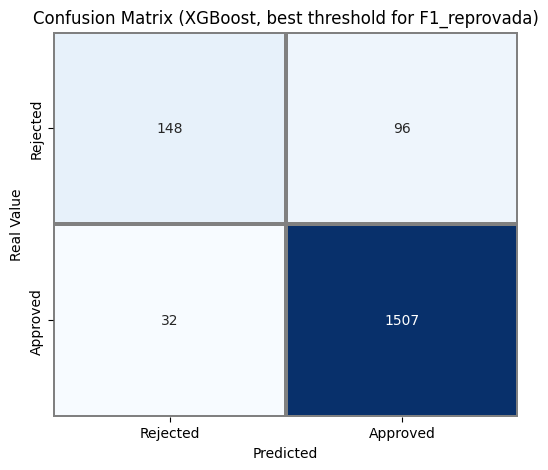


Confusion matrix (XGBoost, optimal threshold for F1_reprovada):
[[ 148   96]
 [  32 1507]]
              precision    recall  f1-score   support

    Rejected      0.822     0.607     0.698       244
    Approved      0.940     0.979     0.959      1539

    accuracy                          0.928      1783
   macro avg      0.881     0.793     0.829      1783
weighted avg      0.924     0.928     0.924      1783

XGBoost AUROC (test): 0.8805
Adding XGBoost predictions to merged_df...
Using X_test index to fetch 'id' from merged_df.
Adjusting prediction Series index to match real 'id' values in merged_df.
Merging predictions into merged_df...
Predictions added to merged_df.
Calculating XGBoost feature importances...

Feature importances (XGBoost):
                    feature  importance
5           gov_orientation    0.483801
7  has_more_than_10_authors    0.198521
6         num_authors_trunc    0.099344
0                popularity    0.059896
8           content_cluster    0.047022
1

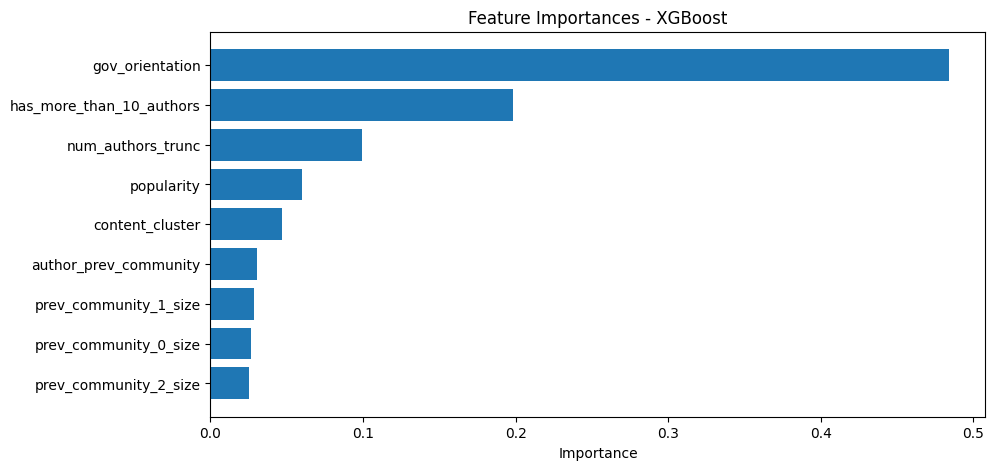

In [16]:
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.cluster import KMeans
from sklearn.metrics import (
    precision_recall_curve, f1_score, classification_report, confusion_matrix, make_scorer, roc_auc_score
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import numpy as np
import pandas as pd

print("Splitting X and y while preserving temporal order...")
X = dataset_features_target[features]
y = dataset_features_target[target]

# Identify numeric features for normalization
numeric_features = [
    'popularity',
    'author_prev_community',
    'prev_community_0_size',
    'prev_community_1_size',
    'prev_community_2_size',
]

# Identify categorical/textual features
categorical_features = [f for f in features if f not in numeric_features]

print("Performing temporal split (80% train, 20% test)...")
split_idx = int(0.8 * len(X))
X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

print("Preparing documents for Doc2Vec (train only)...")
documents = [TaggedDocument(str(text).split(), [i]) for i, text in enumerate(X_train['content'])]

print("Training Doc2Vec model...")
doc2vec_model = Doc2Vec(vector_size=64, min_count=1, epochs=40, workers=4, seed=42)
doc2vec_model.build_vocab(documents)
doc2vec_model.train(documents, total_examples=doc2vec_model.corpus_count, epochs=doc2vec_model.epochs)

print("Inferring Doc2Vec vectors for train set...")
X_train_docvec = np.array([doc2vec_model.infer_vector(str(text).split()) for text in X_train['content']])

print("Clustering train vectors with KMeans...")
n_clusters = 8  # Adjust this value as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
X_train_clusters = kmeans.fit_predict(X_train_docvec)

print("Adding cluster column to X_train...")
X_train_with_cluster = X_train.copy()
X_train_with_cluster['content_cluster'] = X_train_clusters

print("Inferring Doc2Vec vectors for test set...")
X_test_docvec = np.array([doc2vec_model.infer_vector(str(text).split()) for text in X_test['content']])
print("Predicting clusters for test set...")
X_test_clusters = kmeans.predict(X_test_docvec)
X_test_with_cluster = X_test.copy()
X_test_with_cluster['content_cluster'] = X_test_clusters

print("Updating final feature list...")
final_features = [f for f in features if f != 'content'] + ['content_cluster']

print("Normalizing numeric features...")
scaler = StandardScaler()
X_train_scaled = X_train_with_cluster.copy()
X_test_scaled = X_test_with_cluster.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train_with_cluster[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test_with_cluster[numeric_features])

print("Selecting final features for the model...")
X_train_model = X_train_scaled[final_features]
X_test_model = X_test_scaled[final_features]

print("Defining F1 scorer for class 'Rejected' (0)...")
f1_reprovada_scorer = make_scorer(f1_score, pos_label=0, average='binary')

# --------------- XGBoost ONLY ---------------
print("Starting GridSearch for XGBoost...")

from sklearn.model_selection import ParameterGrid
import time

# Try to improve recall for class 0 by using more aggressive class weighting and additional hyperparameters
neg, pos = y_train.value_counts()   # neg = rejected, pos = approved
# Add more aggressive scale_pos_weight values
scale_pos_weights = [1, neg / pos, 2*neg / pos, 3*neg / pos, 5*neg / pos, 10*neg / pos, 20*neg / pos]
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [ 0.05, 0.1],
    'scale_pos_weight': scale_pos_weights,
    'subsample': [0.8],
    'colsample_bytree': [0.6, 0.8],
    'gamma': [0, 1],
    'min_child_weight': [1, 5]
}
total_param_combinations = len(list(ParameterGrid(xgb_param_grid)))
cv_folds = 3
total_fits = total_param_combinations * cv_folds

print(f"GridSearchCV will run {total_param_combinations} parameter combinations x {cv_folds} folds = {total_fits} fits.")

from tqdm.notebook import tqdm

class VerboseGridSearchCV(GridSearchCV):
    def fit(self, X, y=None, **fit_params):
        self._tqdm_bar = tqdm(total=total_fits, desc="GridSearch XGBoost Progress", leave=True)
        from sklearn.model_selection._validation import _fit_and_score as orig_fit_and_score
        def _fit_and_score(*args, **kwargs):
            result = orig_fit_and_score(*args, **kwargs)
            self._tqdm_bar.update(1)
            return result
        import sklearn.model_selection._validation
        old_func = sklearn.model_selection._validation._fit_and_score
        sklearn.model_selection._validation._fit_and_score = _fit_and_score
        try:
            result = super().fit(X, y, **fit_params)
        finally:
            sklearn.model_selection._validation._fit_and_score = old_func
            self._tqdm_bar.close()
        return result

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', tree_method='hist')

# Use the original y (not inverted) and optimize for F1 of class 0 directly
xgb_grid = VerboseGridSearchCV(
    xgb,
    xgb_param_grid,
    scoring=f1_reprovada_scorer,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train_model, y_train)
print(f"XGBoost (GridSearch) best F1_reprovada: {xgb_grid.best_score_:.4f} with params: {xgb_grid.best_params_}")
xgb_best = xgb_grid.best_estimator_

# Get predicted probabilities for class 0
y_proba_0 = xgb_best.predict_proba(X_test_model)[:, 0]
prec_0, rec_0, thresh_0 = precision_recall_curve(y_test, y_proba_0, pos_label=0)
f1_0 = 2 * (prec_0 * rec_0) / (prec_0 + rec_0 + 1e-8)
best_idx_0 = f1_0.argmax()
best_thresh_0 = thresh_0[best_idx_0] if best_idx_0 < len(thresh_0) else 0.5
print(f"Best F1_reprovada = {f1_0[best_idx_0]:.3f} at threshold={best_thresh_0:.2f}")

# Predict using the best threshold for class 0
y_pred_xgb_f1_0 = (y_proba_0 >= best_thresh_0).astype(int) * 0 + (y_proba_0 < best_thresh_0).astype(int) * 1

# --- Visual Confusion Matrix and Metrics Table (like @file_context_0) ---
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_xgb_f1_0)
cm_labels = ["Rejected", "Approved"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=cm_labels, yticklabels=cm_labels, cbar=False, linewidths=1.5, linecolor='gray')
plt.xlabel("Predicted")
plt.ylabel("Real Value")
plt.title("Confusion Matrix (XGBoost, best threshold for F1_reprovada)")
plt.show()

print("\nConfusion matrix (XGBoost, optimal threshold for F1_reprovada):")
print(cm)
print(classification_report(y_test, y_pred_xgb_f1_0, digits=3, target_names=["Rejected","Approved"]))

xgb_auroc = roc_auc_score(y_test, xgb_best.predict_proba(X_test_model)[:, 1])
print(f"XGBoost AUROC (test): {xgb_auroc:.4f}")



# ----------------- ADD XGBOOST PREDICTIONS TO merged_df -----------------
print("Adding XGBoost predictions to merged_df...")

# 1. Get the indices/ids of the test samples
if 'id' in X_test.columns and 'id' in merged_df.columns:
    print("Using 'id' column from X_test and merged_df for alignment.")
    test_ids = X_test['id'].values
elif 'id' in merged_df.columns:
    print("Using X_test index to fetch 'id' from merged_df.")
    test_ids = X_test.index
else:
    print("No 'id' column found, using index.")
    test_ids = X_test.index

# 2. Get model predictions for the test set (using optimal threshold for F1_reprovada)
y_pred_xgb_final = y_pred_xgb_f1_0

# 3. Create a Series with results, indexed by ids
pred_series = pd.Series(y_pred_xgb_final, index=test_ids, name='aprovacao_predita_xgb')

# 4. Add prediction column to merged_df
if 'id' in merged_df.columns:
    if 'id' not in X_test.columns:
        print("Adjusting prediction Series index to match real 'id' values in merged_df.")
        test_ids_real = merged_df.loc[test_ids, 'id']
        pred_series.index = test_ids_real
    if 'aprovacao_predita_xgb' in merged_df.columns:
        print("Removing existing 'aprovacao_predita_xgb' column from merged_df to avoid merge conflict.")
        merged_df = merged_df.drop(columns=['aprovacao_predita_xgb'])
    print("Merging predictions into merged_df...")
    merged_df = merged_df.merge(pred_series, left_on='id', right_index=True, how='left')
else:
    print("Adding 'aprovacao_predita_xgb' column directly to merged_df (no 'id' column).")
    merged_df['aprovacao_predita_xgb'] = pred_series

print("Predictions added to merged_df.")

# ----------------- XGBOOST FEATURE IMPORTANCE -----------------
import matplotlib.pyplot as plt

print("Calculating XGBoost feature importances...")
importances = xgb_best.feature_importances_
feature_names = X_train_model.columns

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

print("\nFeature importances (XGBoost):")
print(importance_df)

plt.figure(figsize=(10,5))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title('Feature Importances - XGBoost')
plt.gca().invert_yaxis()
plt.show()


Running SHAP explanations for XGBoost...


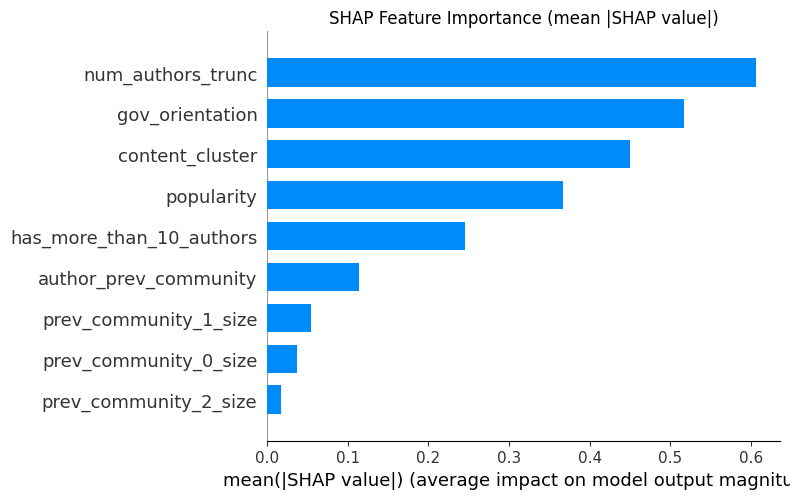

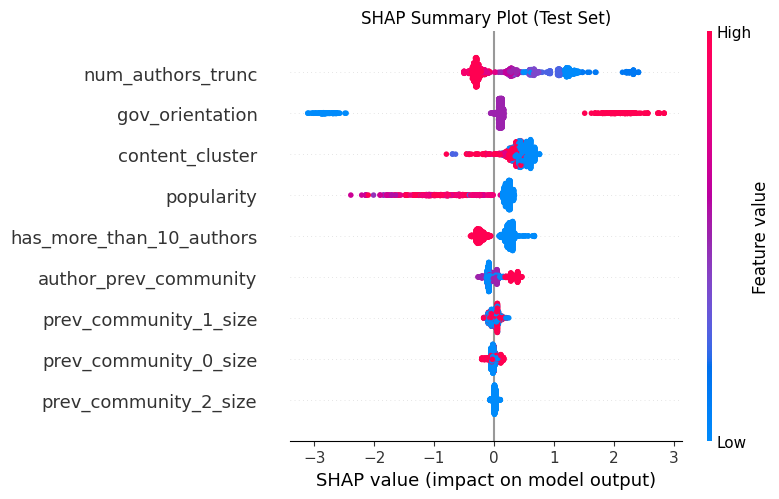

SHAP force plot for the first test sample:


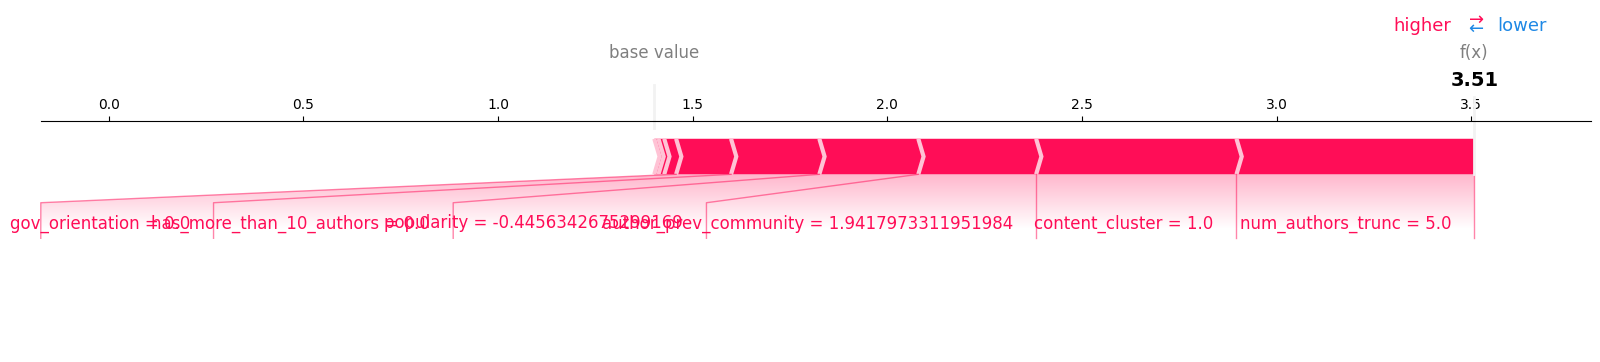

None

In [18]:
# SHAP explanation for XGBoost model

import shap

print("Running SHAP explanations for XGBoost...")

# Use TreeExplainer for XGBoost
explainer = shap.TreeExplainer(xgb_best)
# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test_model)

# Summary plot (bar) - mean absolute SHAP value per feature
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_model, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (mean |SHAP value|)")
plt.tight_layout()
plt.show()

# Summary plot (beeswarm) - distribution of SHAP values per feature
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test_model, show=False)
plt.title("SHAP Summary Plot (Test Set)")
plt.tight_layout()
plt.show()

# Optional: Show SHAP force plot for a few individual predictions
# (force plot works best in Jupyter, but we can show for the first test sample)
print("SHAP force plot for the first test sample:")
shap.initjs()
display(shap.force_plot(explainer.expected_value, shap_values[0,:], X_test_model.iloc[0,:], matplotlib=True))


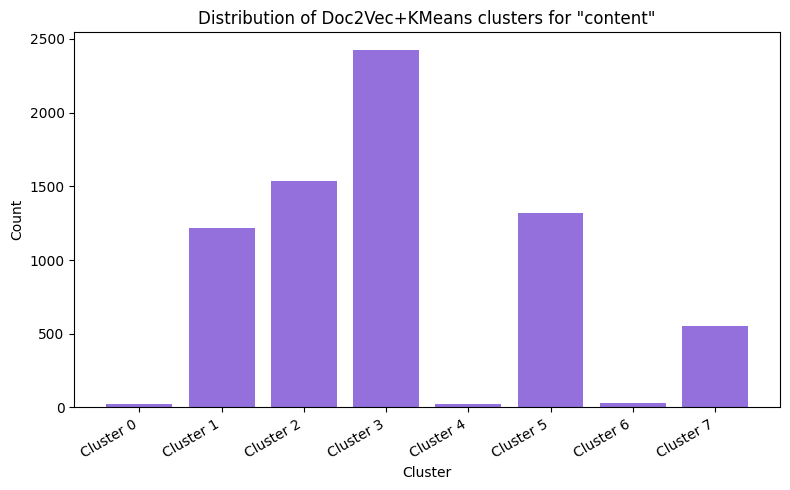

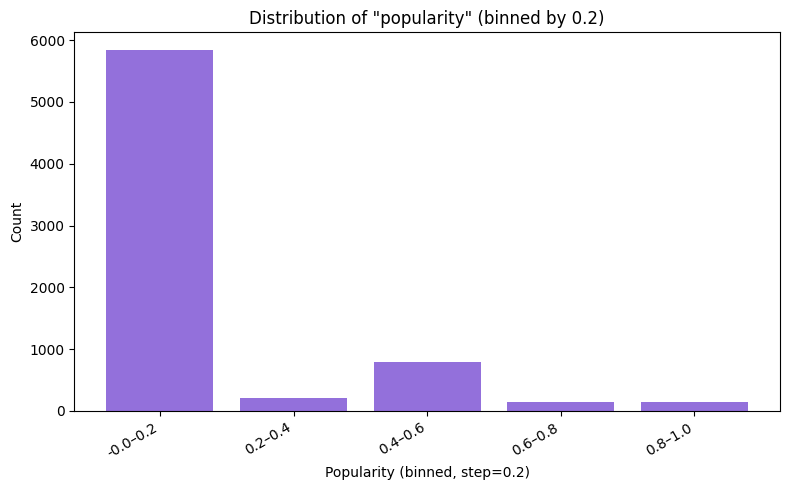

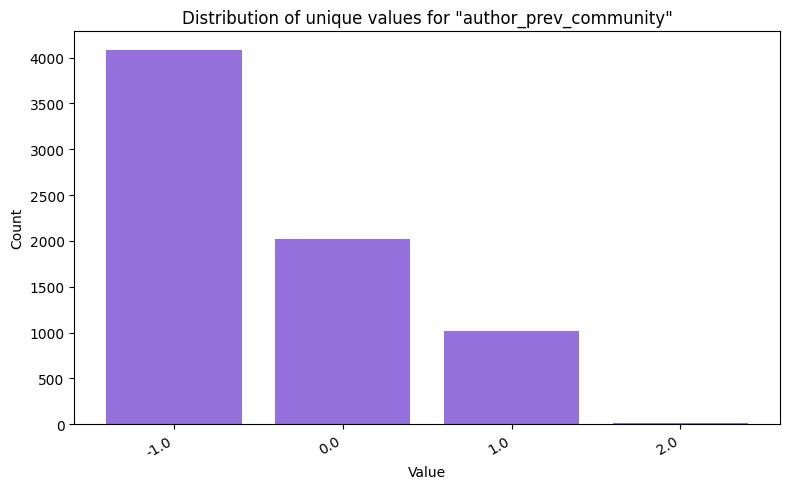

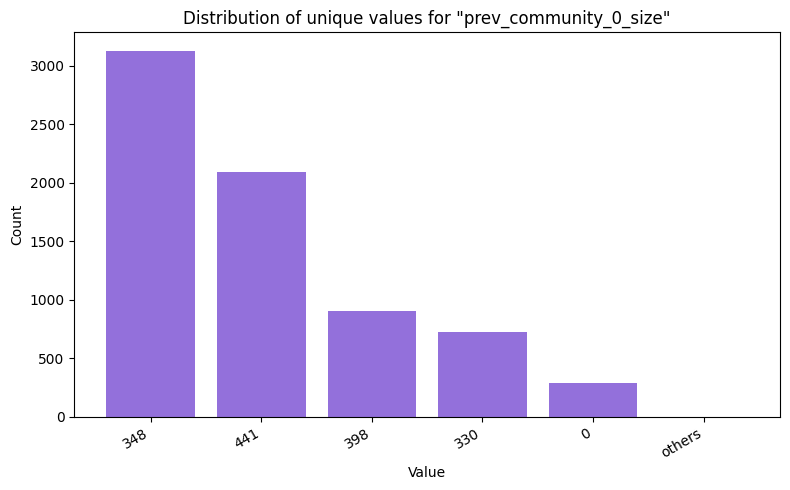

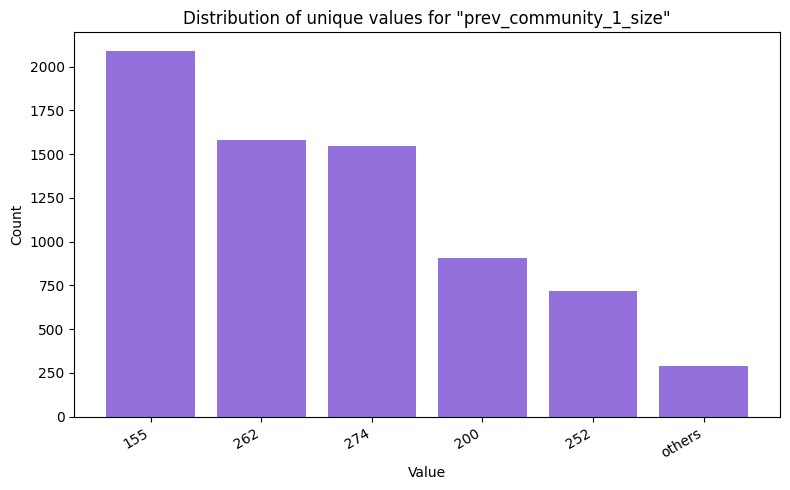

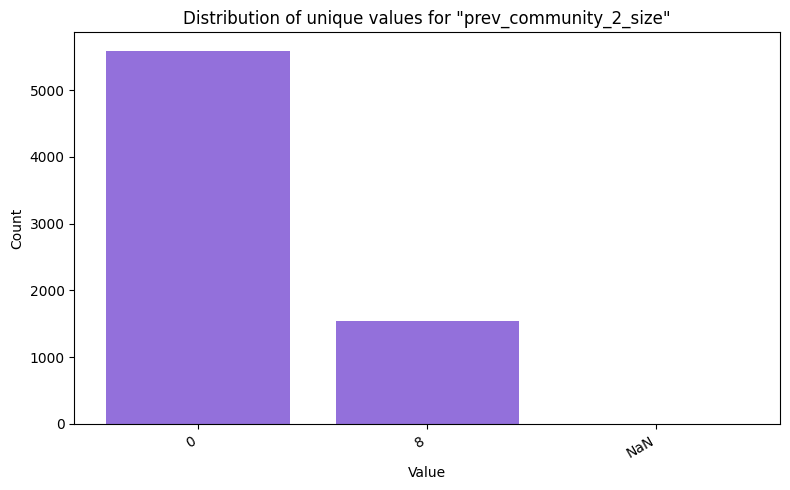

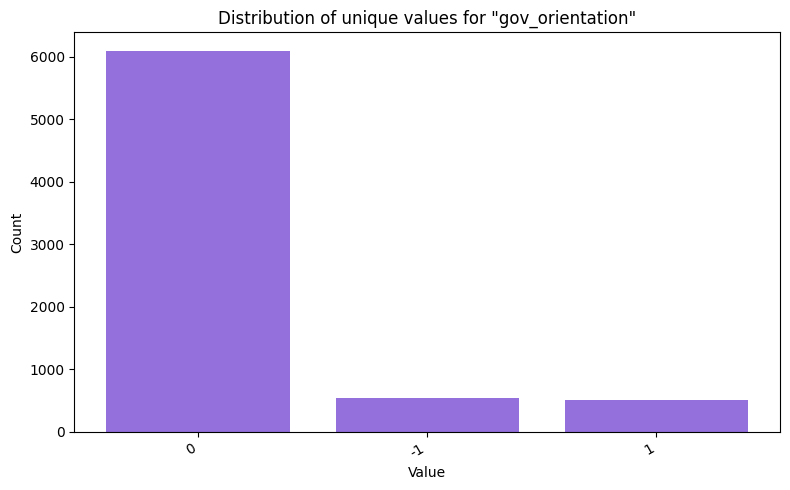

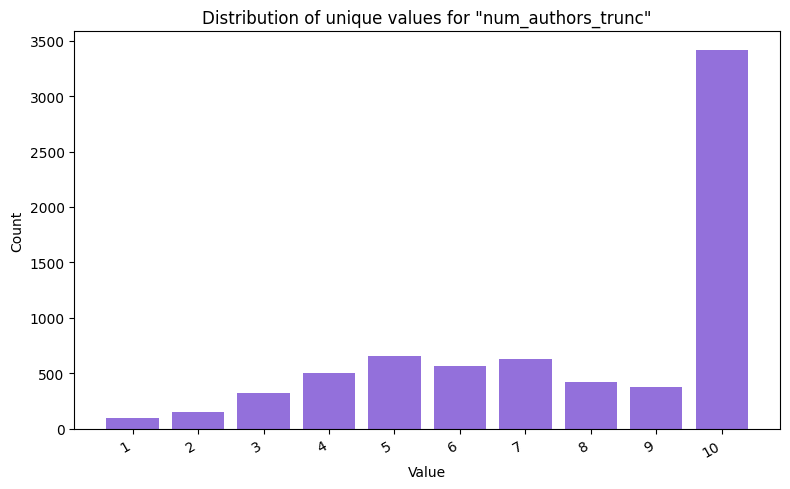

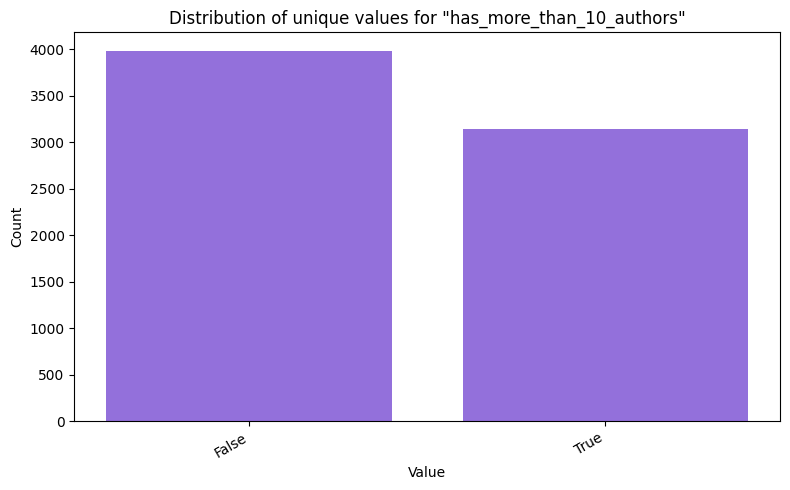

In [25]:
for feat in features:
    if feat == "content":
        # For "content", show distribution of KMeans clusters from Doc2Vec
        # Use same parameters as in prepare_X
        documents = [TaggedDocument(str(text).split(), [i]) for i, text in enumerate(train_df['content'])]
        doc2vec_model = Doc2Vec(vector_size=64, min_count=1, epochs=40, workers=4, seed=42)
        doc2vec_model.build_vocab(documents)
        doc2vec_model.train(documents, total_examples=doc2vec_model.corpus_count, epochs=doc2vec_model.epochs)
        X_train_docvec = np.array([doc2vec_model.infer_vector(str(text).split()) for text in train_df['content']])
        n_clusters = 8
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        X_train_clusters = kmeans.fit_predict(X_train_docvec)
        # Count the number of samples in each cluster
        cluster_counts = pd.Series(X_train_clusters).value_counts().sort_index()
        cluster_labels = [f"Cluster {i}" for i in cluster_counts.index]
        plt.figure(figsize=(8, 5))
        plt.bar(cluster_labels, cluster_counts.values, color='mediumpurple')
        plt.xlabel('Cluster')
        plt.ylabel('Count')
        plt.title('Distribution of Doc2Vec+KMeans clusters for "content"')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()
    elif feat == "num_authors_trunc":
        # For num_authors_trunc, show all x values (do not group as "others")
        value_counts = train_df[feat].value_counts(dropna=False).sort_index()
        def format_label(x):
            s = str(x) if pd.notnull(x) else 'NaN'
            return s[:10] + ('…' if len(s) > 10 else '')
        plot_counts = value_counts
        plot_counts.index = plot_counts.index.map(format_label)
        plt.figure(figsize=(8, 5))
        plt.bar(plot_counts.index, plot_counts.values, color='mediumpurple')
        plt.xlabel('Value')
        plt.ylabel('Count')
        plt.title(f'Distribution of unique values for "{feat}"')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()
    elif feat == "popularity":
        # For "popularity", bin values in steps of 0.2 from 0 to 1
        popularity_values = train_df[feat]
        bins = np.arange(0, 1.01, 0.2)  # [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
        # Ensure the rightmost edge includes 1.0
        binned = pd.cut(popularity_values, bins=bins, include_lowest=True, right=True)
        value_counts = binned.value_counts(sort=False)
        # Format bin labels as strings
        def format_bin_label(interval):
            left = interval.left
            right = interval.right
            # For the last bin, include the right edge as closed
            if right == 1.0:
                return f"{left:.1f}–{right:.1f}"
            else:
                return f"{left:.1f}–{right:.1f}"
        plot_counts = value_counts
        plot_counts.index = plot_counts.index.map(format_bin_label)
        plt.figure(figsize=(8, 5))
        plt.bar(plot_counts.index, plot_counts.values, color='mediumpurple')
        plt.xlabel('Popularity (binned, step=0.2)')
        plt.ylabel('Count')
        plt.title('Distribution of "popularity" (binned by 0.2)')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        value_counts = train_df[feat].value_counts(dropna=False)
        # If more than 5 unique values, group the rest as "others"
        if len(value_counts) > 5:
            top5 = value_counts.iloc[:5]
            others_count = value_counts.iloc[5:].sum()
            top5['others'] = others_count
            plot_counts = top5
        else:
            plot_counts = value_counts
        # Convert index to string for better labeling, and limit to 10 characters
        def format_label(x):
            s = str(x) if pd.notnull(x) else 'NaN'
            return s[:10] + ('…' if len(s) > 10 else '')
        plot_counts.index = plot_counts.index.map(format_label)
        # Sort from highest to lowest
        plot_counts = plot_counts.sort_values(ascending=False)
        plt.figure(figsize=(8, 5))
        plt.bar(plot_counts.index, plot_counts.values, color='mediumpurple')
        plt.xlabel('Value')
        plt.ylabel('Count')
        plt.title(f'Distribution of unique values for "{feat}"')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()


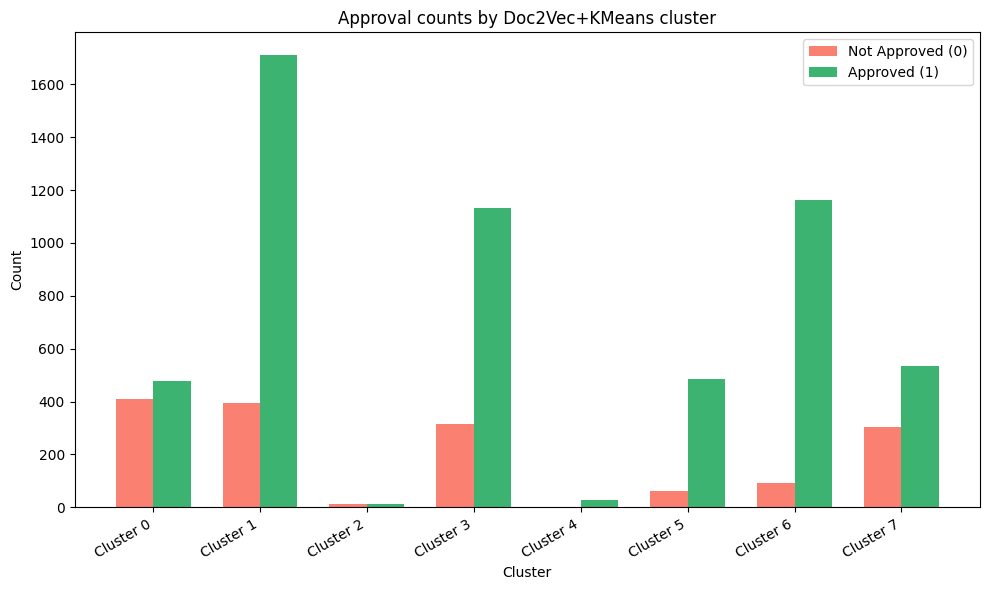

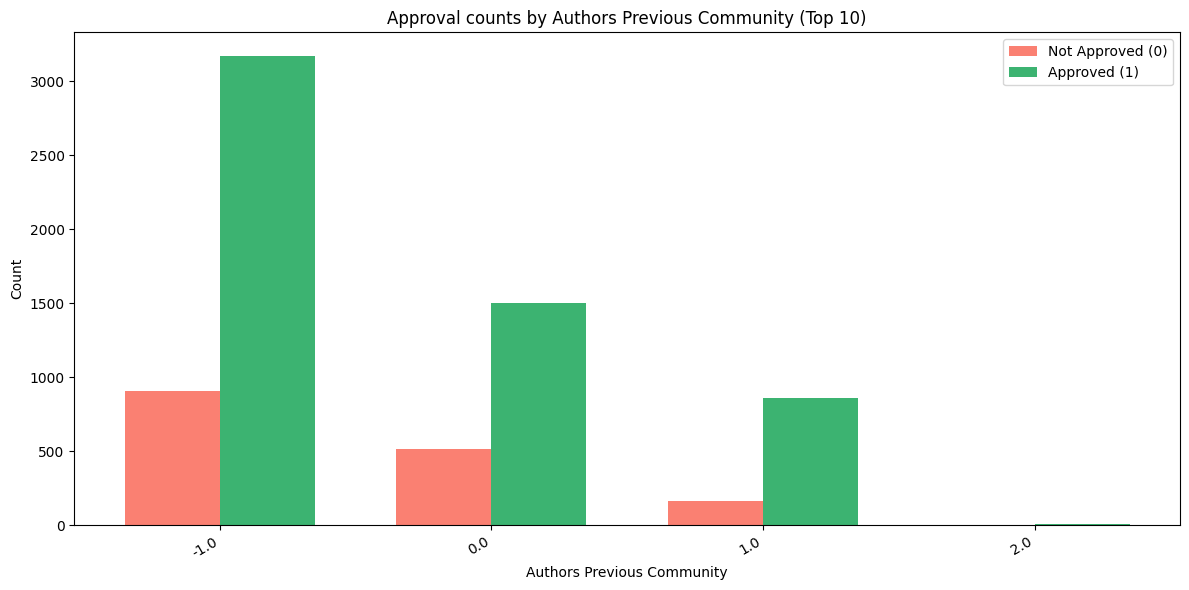

In [20]:
# --- Doc2Vec+KMeans clusters: Approval counts per cluster ---

# Ensure X_train_clusters and train_df are aligned by index
train_df_with_clusters = train_df.copy()
train_df_with_clusters['cluster'] = X_train_clusters

# Merge aprovacao from merged_df if not present
if 'aprovacao' not in train_df_with_clusters.columns:
    train_df_with_clusters = train_df_with_clusters.merge(
        merged_df[['id', 'aprovacao']], on='id', how='left'
    )

# Group by cluster and aprovacao, then count
cluster_aprov_counts = train_df_with_clusters.groupby(['cluster', 'aprovacao']).size().unstack(fill_value=0)

# Plot the counts for each cluster
cluster_labels = [f"Cluster {i}" for i in range(n_clusters)]
approved_counts = cluster_aprov_counts.get(1, pd.Series([0]*n_clusters, index=range(n_clusters)))
not_approved_counts = cluster_aprov_counts.get(0, pd.Series([0]*n_clusters, index=range(n_clusters)))

x = np.arange(n_clusters)
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, not_approved_counts, width, label='Not Approved (0)', color='salmon')
plt.bar(x + width/2, approved_counts, width, label='Approved (1)', color='mediumseagreen')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.title('Approval counts by Doc2Vec+KMeans cluster')
plt.xticks(x, cluster_labels, rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# --- authors previous community: Approval counts per value ---

# If 'authors previous community' is not in train_df, try merged_df
if 'author_prev_community' in train_df.columns:
    community_df = train_df.copy()
elif 'author_prev_community' in merged_df.columns:
    community_df = merged_df[merged_df['id'].isin(train_df['id'])].copy()
else:
    raise ValueError("Feature 'authors previous community' not found in train_df or merged_df.")

# Merge aprovacao if not present
if 'aprovacao' not in community_df.columns:
    community_df = community_df.merge(
        merged_df[['id', 'aprovacao']], on='id', how='left'
    )

# Group by 'authors previous community' and aprovacao, then count
community_aprov_counts = community_df.groupby(['author_prev_community', 'aprovacao']).size().unstack(fill_value=0)

# Sort by total count descending and limit to top 10 communities for clarity
top_communities = community_aprov_counts.sum(axis=1).sort_values(ascending=False).head(10).index
plot_counts = community_aprov_counts.loc[top_communities]

# Plot
x = np.arange(len(plot_counts))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, plot_counts.get(0, pd.Series([0]*len(plot_counts), index=plot_counts.index)), width, label='Not Approved (0)', color='salmon')
plt.bar(x + width/2, plot_counts.get(1, pd.Series([0]*len(plot_counts), index=plot_counts.index)), width, label='Approved (1)', color='mediumseagreen')
plt.xlabel('Authors Previous Community')
plt.ylabel('Count')
plt.title('Approval counts by Authors Previous Community (Top 10)')
plt.xticks(x, [str(c)[:15] + ('…' if len(str(c)) > 15 else '') for c in plot_counts.index], rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

